In [2]:
#Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
#Load the dataset
from google.colab import files
uploaded = files.upload()

Saving google_play_store_dataset.csv to google_play_store_dataset.csv


In [4]:
df = pd.read_csv("google_play_store_dataset.csv")
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [5]:
#First inspection
df.shape
df.info()
df.isnull().sum().sort_values(ascending=False)
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Remove duplicates
df.duplicated().sum()

np.int64(483)

In [7]:
df = df.drop_duplicates()

In [8]:
#Clean reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors='coerce')

In [9]:
#Clean Installs
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [10]:
#Clean price
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [11]:
#Clean size
def clean_size(size):
  if pd.isna(size):
    return np.nan
  if size == "Varies with device":
    return np.nan
  if "M" in size:
    return float(size.replace("M", ""))
  if "k" in size:
    return float(size.replace("k", "")) / 1024
  return np.nan
df["Size"] = df["Size"].apply(clean_size)

In [12]:
#Convert rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [13]:
#Handle missing values
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])
df["Content Rating"] = df["Content Rating"].fillna(df["Content Rating"].mode()[0])
df["Current Ver"] = df["Current Ver"].fillna("Unknown")
df["Android Ver"] = df["Android Ver"].fillna("Unknown")

In [14]:
#Fixed dataset
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          10358 non-null  float64
 3   Reviews         10357 non-null  float64
 4   Size            8831 non-null   float64
 5   Installs        10357 non-null  float64
 6   Type            10358 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10358 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10358 non-null  object 
 12  Android Ver     10358 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.1+ MB


,0
Size,1527
Reviews,1
Installs,1
Price,1
App,0
Category,0
Rating,0
Type,0
Content Rating,0
Genres,0


In [ ]:
################################
#### Exploratory Analysis ######
################################

In [15]:
df["Category"].value_counts().head(10)

,count
Category,
FAMILY,1943
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


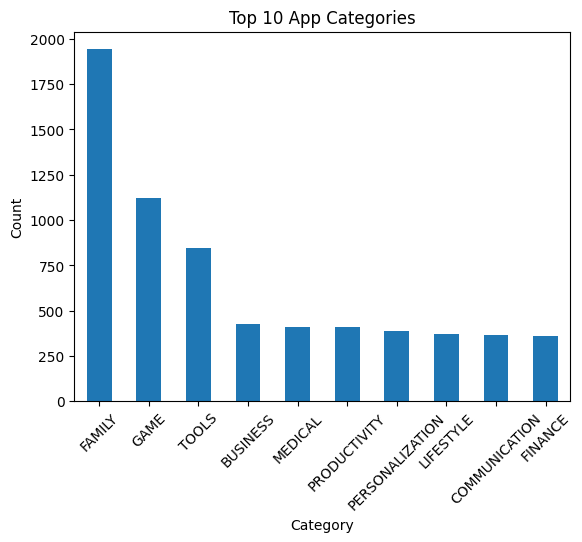

In [16]:
df["Category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

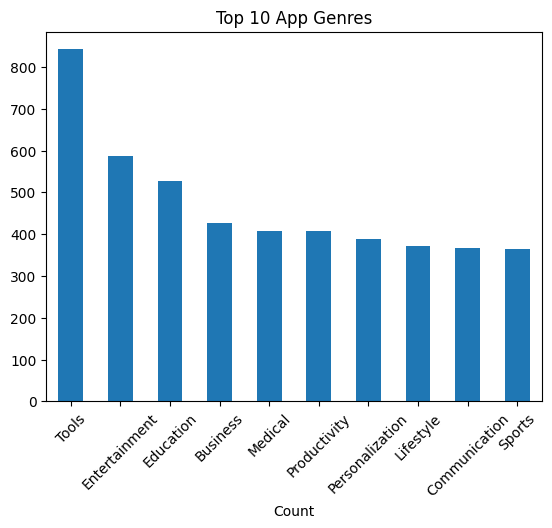

In [17]:
df["Genres"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 App Genres")
plt.xlabel("Genres")
plt.xlabel("Count")
plt.xticks(rotation=45)
plt.show()

In [18]:
#Average rating by category
category_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
category_rating.head(10)

,Rating
Category,
1.9,19.000000
EVENTS,4.395313
EDUCATION,4.375385
ART_AND_DESIGN,4.355385
BOOKS_AND_REFERENCE,4.336522
PERSONALIZATION,4.327062
PARENTING,4.300000
BEAUTY,4.283019
GAME,4.282070


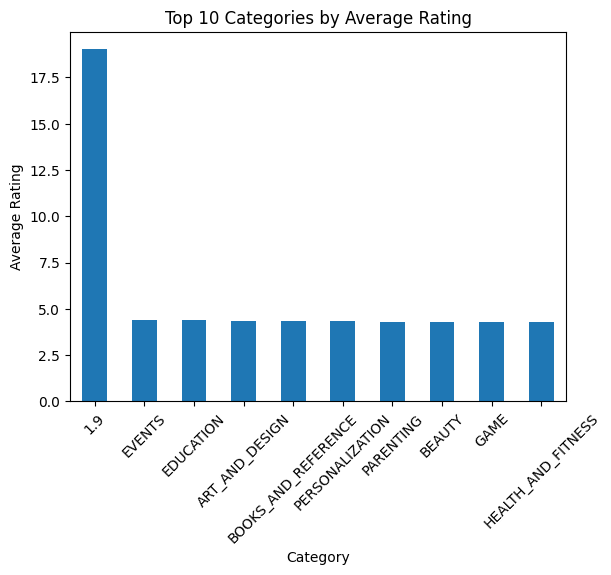

In [19]:
category_rating.head(10).plot(kind='bar')
plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [20]:
#Free vs paid ads
df["Type"].value_counts()

,count
Type,
Free,9592
Paid,765
0,1


In [21]:
df.groupby("Type")["Rating"].mean()

,Rating
Type,
0,19.00000
Free,4.19852
Paid,4.26915


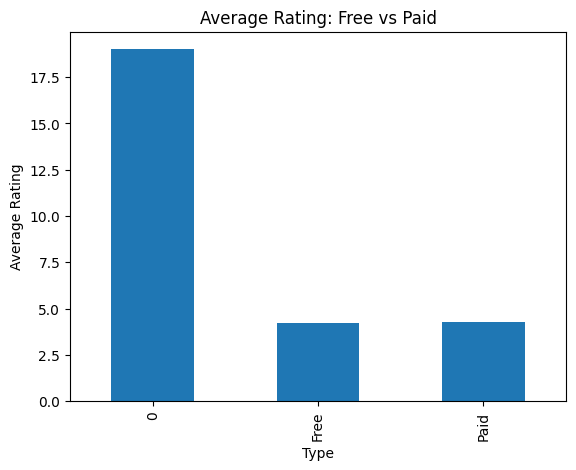

In [22]:
df.groupby("Type")["Rating"].mean().plot(kind="bar")
plt.title("Average Rating: Free vs Paid")
plt.ylabel("Average Rating")
plt.show()

In [24]:
df[df["Category"] == 1.9]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [25]:
#Remove the 1.9 category
df = df[df["Category"] != "1.9"]

In [26]:
#Fixed check
df.groupby("Type")["Rating"].mean()

,Rating
Type,
Free,4.19852
Paid,4.26915


In [27]:
#Category with most installs
category_installs = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)
category_installs.head(10)

,Installs
Category,
GAME,3.154402e+10
COMMUNICATION,2.415228e+10
SOCIAL,1.251387e+10
PRODUCTIVITY,1.246309e+10
TOOLS,1.145277e+10
FAMILY,1.004169e+10
PHOTOGRAPHY,9.721248e+09
TRAVEL_AND_LOCAL,6.361887e+09
VIDEO_PLAYERS,6.222003e+09


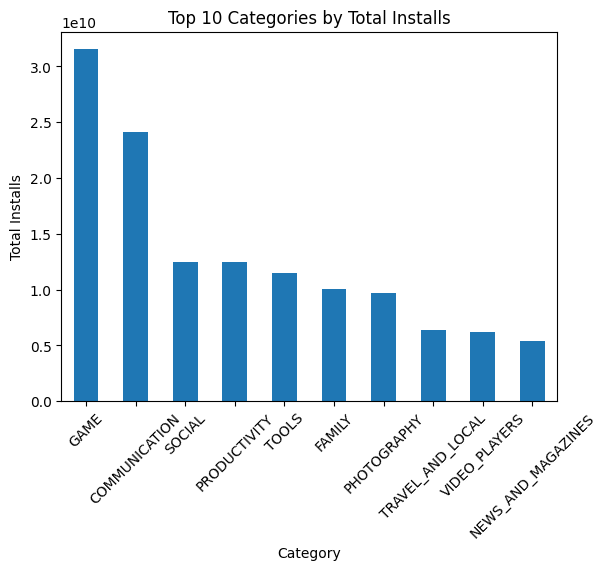

In [28]:
category_installs.head(10).plot(kind="bar")
plt.title("Top 10 Categories by Total Installs")
plt.xlabel('Category')
plt.ylabel("Total Installs")
plt.xticks(rotation=45)
plt.show()

In [29]:
#Paid apps price analysis
paid_apps = df[df["Type"] == "Paid"]
paid_apps["Price"].describe()

,Price
count,765.000000
mean,13.955556
std,58.406966
min,0.990000
25%,1.490000
50%,2.990000
75%,4.990000
max,400.000000


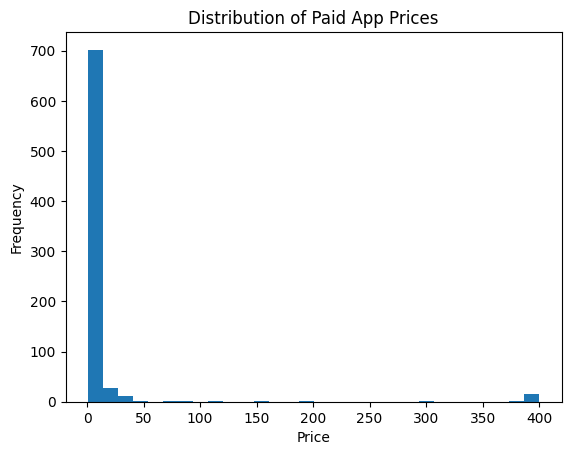

In [30]:
paid_apps["Price"].plot(kind="hist", bins=30)
plt.title("Distribution of Paid App Prices")
plt.xlabel("Price")
plt.show()

Questions

**Which column had the most cleaning issues?**
The columns with the most cleaning issues were the ones stored as text instead of numeric values, especially Installs, Price, Size, and Reviews. I also found an invalid row where the category appeared as 1.9, which had to be removed.

**Which category has the most apps?**
The Family category has the highest number of apps in the dataset.

**Which category has the highest average rating?**
Free and paid apps have very similar average ratings, so price type does not seem to strongly affect app rating in this dataset.

**Do free or paid apps have a higher average rating?** Free and paid apps have very similar average ratings, so price type does not seem to strongly affect app rating in this dataset.

**Which category has the most installs?** The Game category has the highest total number of installs.

**What does the price distribution of paid apps look like?** Most paid apps are concentrated in the lower price range, mainly between $0 and $50, with fewer apps at higher prices.